# 📦 01 — Data Loading & Exploratory Data Analysis
## Olist Brazilian E-Commerce Dataset

This notebook loads the raw Olist dataset, performs data quality checks, and creates initial visualizations to understand the data before processing.

**Dataset**: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Period**: September 2016 – August 2018  
**Source**: Real-world transactional data from a Brazilian marketplace

---

## 1. Setup & Imports

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
import config

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Project Root: {config.PROJECT_ROOT}")
print(f"Olist Data Dir: {config.DATA_OLIST_RAW}")
print(f"Analysis Date: {config.ANALYSIS_DATE.date()}")

Project Root: d:\Customer Profitability and Retention Analytics
Olist Data Dir: d:\Customer Profitability and Retention Analytics\data\raw\olist
Analysis Date: 2018-09-01


## 2. Load Raw Olist Files

The Olist dataset consists of 8 CSV files. We load each and inspect shape, dtypes, and null counts.

In [4]:
# Load all raw files
raw_dir = config.DATA_OLIST_RAW
print("Loading data from:", raw_dir) # Add

customers_raw = pd.read_csv(os.path.join(raw_dir, 'olist_customers_dataset.csv'))
orders_raw = pd.read_csv(os.path.join(raw_dir, 'olist_orders_dataset.csv'))
items_raw = pd.read_csv(os.path.join(raw_dir, 'olist_order_items_dataset.csv'))
payments_raw = pd.read_csv(os.path.join(raw_dir, 'olist_order_payments_dataset.csv'))
products_raw = pd.read_csv(os.path.join(raw_dir, 'olist_products_dataset.csv'))
category_trans = pd.read_csv(os.path.join(raw_dir, 'olist_product_category_name_translation.csv'))

# Optional files
reviews_path = os.path.join(raw_dir, 'olist_order_reviews_dataset.csv')
reviews_raw = pd.read_csv(reviews_path) if os.path.exists(reviews_path) else None

datasets = {
    'Customers': customers_raw,
    'Orders': orders_raw,
    'Order Items': items_raw,
    'Payments': payments_raw,
    'Products': products_raw,
    'Category Translation': category_trans,
}
if reviews_raw is not None:
    datasets['Reviews'] = reviews_raw

# Summary table
summary = pd.DataFrame({
    'Table': datasets.keys(),
    'Rows': [len(df) for df in datasets.values()],
    'Columns': [len(df.columns) for df in datasets.values()],
    'Null Columns': [df.isnull().any().sum() for df in datasets.values()],
})
print(summary.to_string(index=False))

Loading data from: d:\Customer Profitability and Retention Analytics\data\raw\olist
               Table   Rows  Columns  Null Columns
           Customers  99441        5             0
              Orders  99441        8             3
         Order Items 112650        7             0
            Payments 103886        5             0
            Products  32951        9             8
Category Translation     71        2             0
             Reviews  99224        7             2


## 3. Data Quality Inspection

In [ ]:
# Inspect each table
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name} — {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'='*60}")
    print(f"\nColumn Types:")
    print(df.dtypes.to_string())
    print(f"\nNull Counts:")
    nulls = df.isnull().sum()
    print(nulls[nulls > 0].to_string() if nulls.any() else '  No nulls!')
    print(f"\nSample Rows:")
    print(df.head(3))


  Customers — 99,441 rows × 5 columns

Column Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object

Null Counts:
  No nulls!

Sample Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



  Orders — 99,441 rows × 8 columns

Column Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

Null Counts:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

Sample Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



  Order Items — 112,650 rows × 7 columns

Column Types:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64

Null Counts:
  No nulls!

Sample Rows:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00



  Category Translation — 71 rows × 2 columns

Column Types:
product_category_name            object
product_category_name_english    object

Null Counts:
  No nulls!

Sample Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



  Reviews — 99,224 rows × 7 columns

Column Types:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object

Null Counts:
review_comment_title      87656
review_comment_message    58247

Sample Rows:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


## 4. Orders — Time Distribution

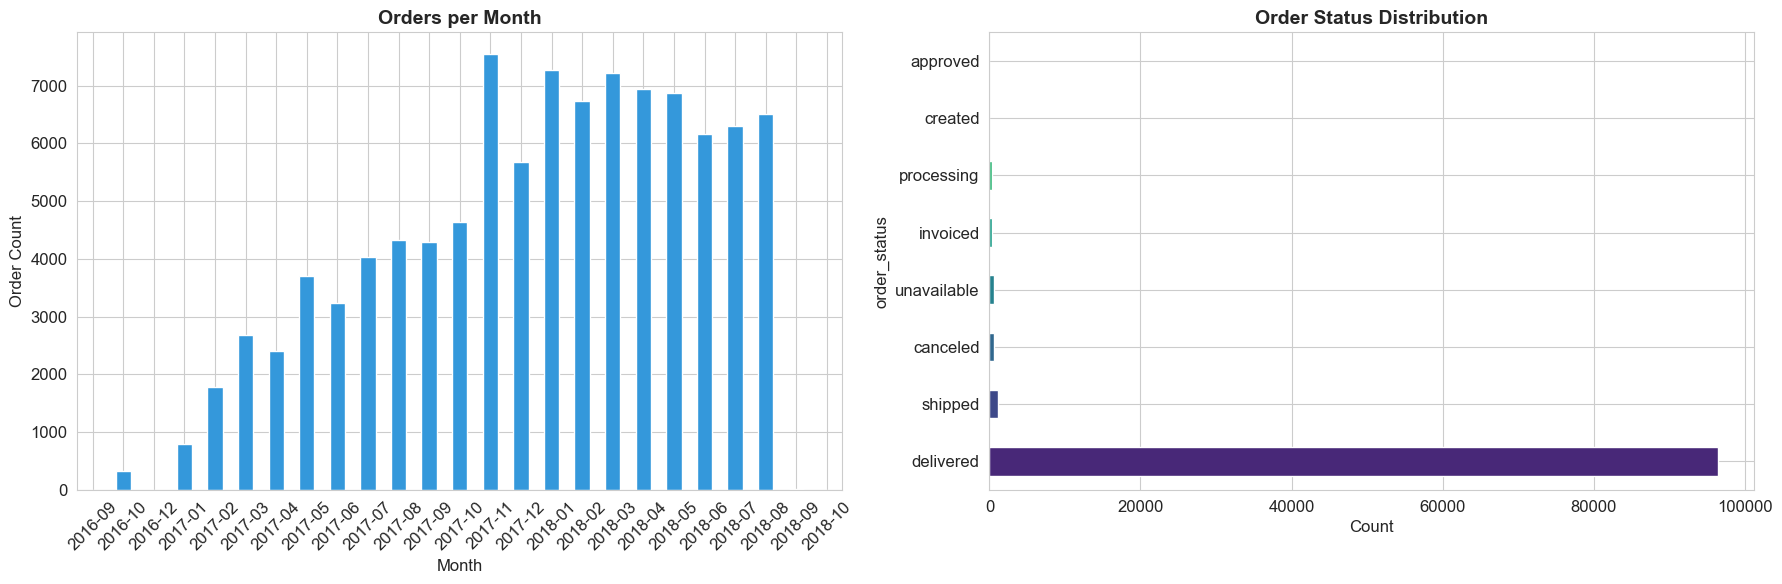


Date Range: 2016-09-04 → 2018-10-17
Total Orders: 99,441
Unique Customers: 99,441


In [6]:
orders_raw['order_purchase_timestamp'] = pd.to_datetime(orders_raw['order_purchase_timestamp'])
orders_raw['order_month'] = orders_raw['order_purchase_timestamp'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Orders per month
monthly_orders = orders_raw.groupby('order_month').size()
monthly_orders.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Orders per Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=45)

# Order status distribution
status_counts = orders_raw['order_status'].value_counts()
status_counts.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', len(status_counts)))
axes[1].set_title('Order Status Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"\nDate Range: {orders_raw['order_purchase_timestamp'].min().date()} → {orders_raw['order_purchase_timestamp'].max().date()}")
print(f"Total Orders: {len(orders_raw):,}")
print(f"Unique Customers: {orders_raw['customer_id'].nunique():,}")

## 5. Geographic Distribution

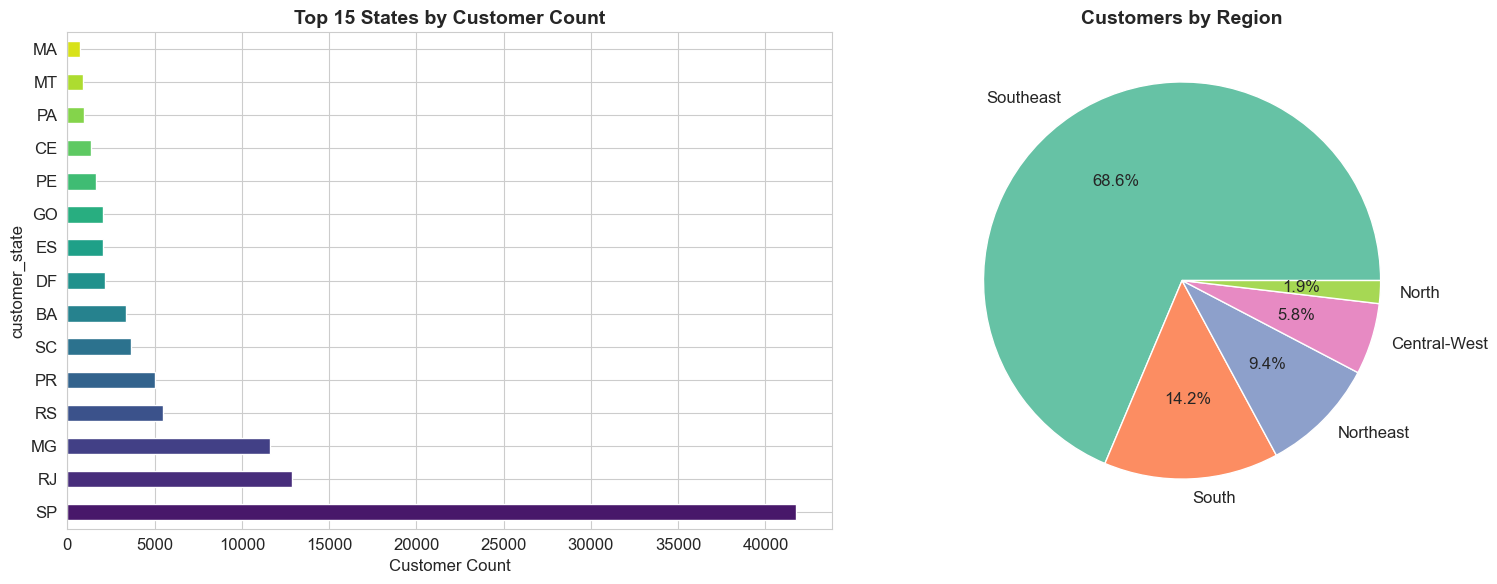

In [7]:
# Customer distribution by state
state_counts = customers_raw['customer_state'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(state_counts)))
axes[0].set_title('Top 15 States by Customer Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Customer Count')

# Region distribution
customers_raw['region'] = customers_raw['customer_state'].map(config.BRAZILIAN_REGIONS)
region_counts = customers_raw['region'].value_counts()
region_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Customers by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 6. Product Category Analysis

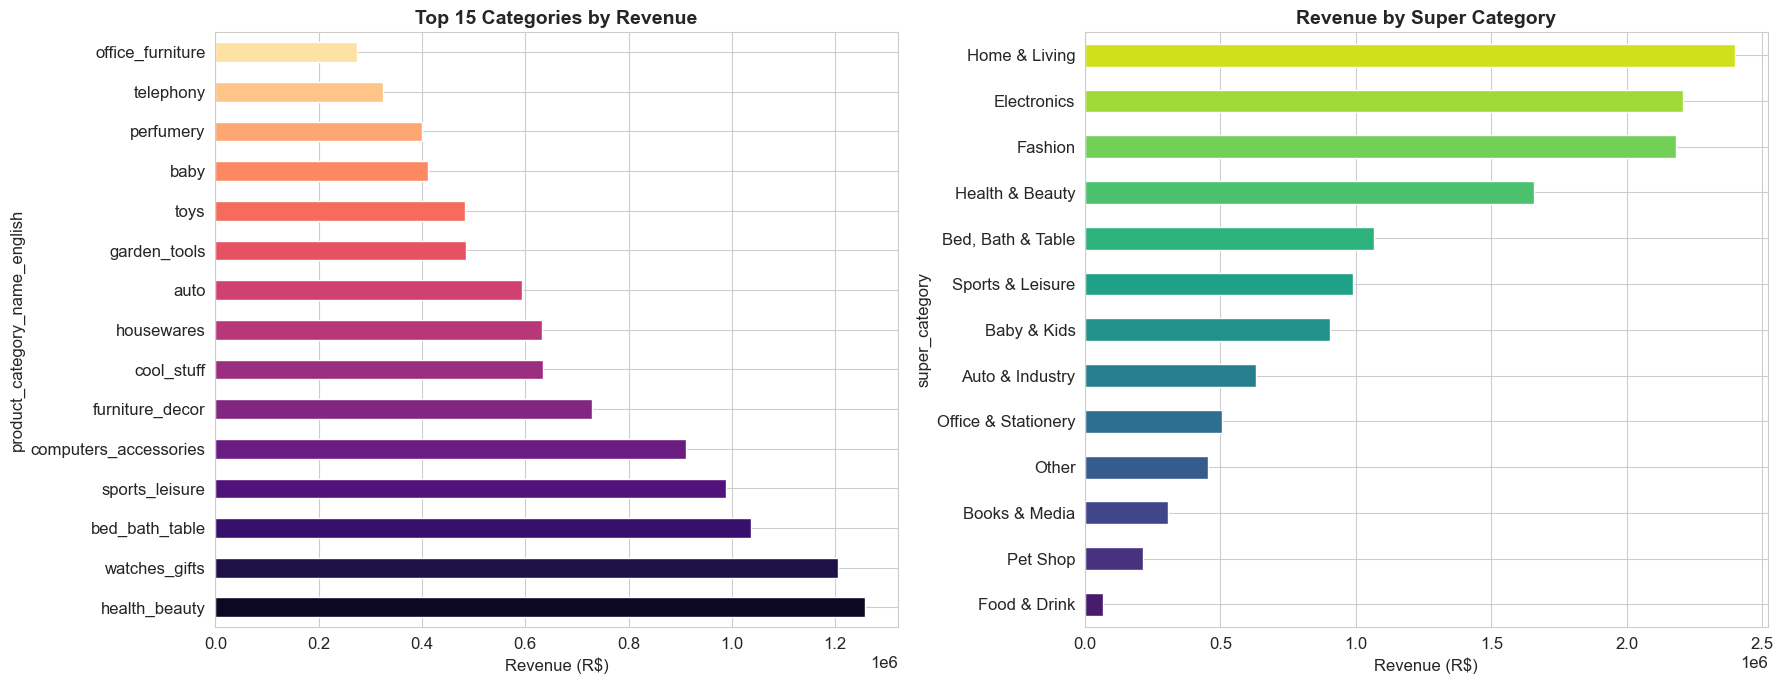


Total product categories: 71
Super categories: 13


In [8]:
# Translate categories and show distribution
products_translated = products_raw.merge(category_trans, on='product_category_name', how='left')
items_with_cats = items_raw.merge(products_translated[['product_id', 'product_category_name_english']], on='product_id', how='left')

# Map to super categories
items_with_cats['super_category'] = (
    items_with_cats['product_category_name_english']
    .str.lower().str.strip()
    .map(config.PRODUCT_SUPER_CATEGORIES)
    .fillna('Other')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 product categories by revenue
cat_revenue = items_with_cats.groupby('product_category_name_english')['price'].sum().nlargest(15)
cat_revenue.plot(kind='barh', ax=axes[0], color=sns.color_palette('magma', 15))
axes[0].set_title('Top 15 Categories by Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'Revenue ({config.CURRENCY_SYMBOL})')

# Super category distribution
super_revenue = items_with_cats.groupby('super_category')['price'].sum().sort_values(ascending=True)
super_revenue.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', len(super_revenue)))
axes[1].set_title('Revenue by Super Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'Revenue ({config.CURRENCY_SYMBOL})')

plt.tight_layout()
plt.show()

print(f"\nTotal product categories: {items_with_cats['product_category_name_english'].nunique()}")
print(f"Super categories: {items_with_cats['super_category'].nunique()}")

## 7. Payment Analysis

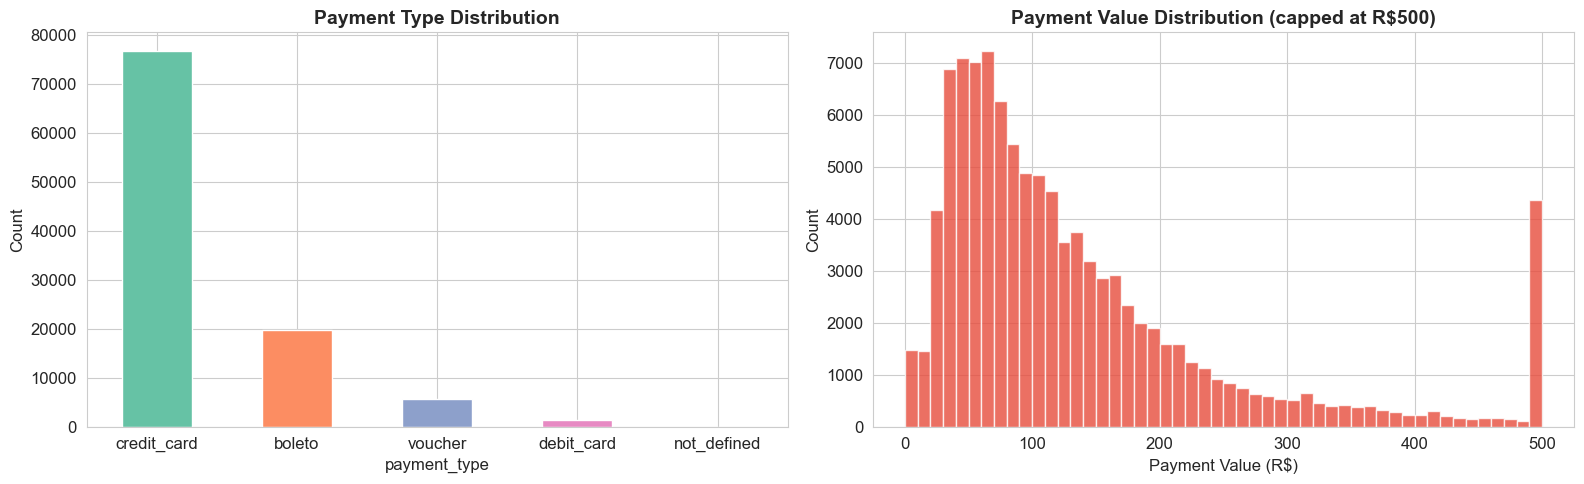


Payment Stats:
count   103886.00
mean       154.10
std        217.49
min          0.00
25%         56.79
50%        100.00
75%        171.84
max      13664.08
Name: payment_value, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Payment type distribution
payment_types = payments_raw['payment_type'].value_counts()
payment_types.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Payment Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Payment value distribution
axes[1].hist(payments_raw['payment_value'].clip(0, 500), bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_title('Payment Value Distribution (capped at R$500)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'Payment Value ({config.CURRENCY_SYMBOL})')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nPayment Stats:")
print(payments_raw['payment_value'].describe().round(2))

## 8. Review Scores (if available)

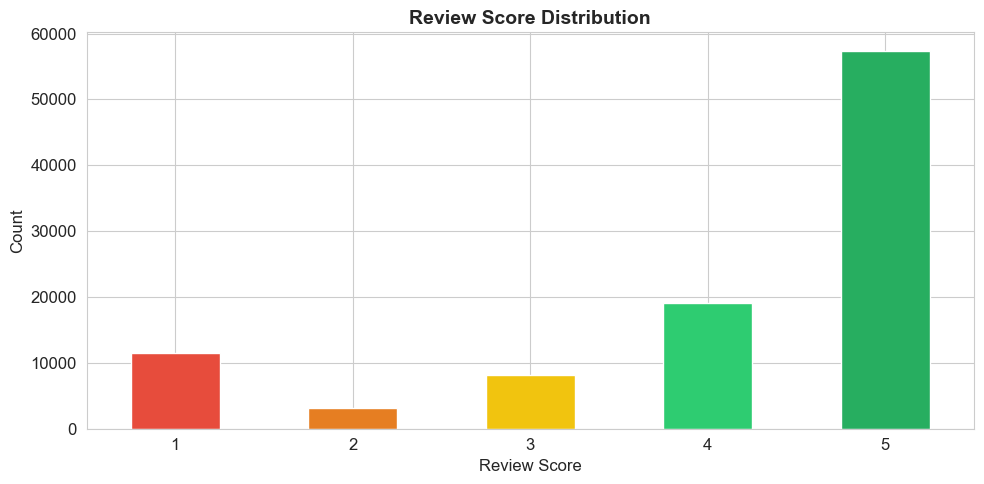


Avg Review Score: 4.09
Total Reviews: 99,224


In [10]:
if reviews_raw is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    reviews_raw['review_score'].value_counts().sort_index().plot(
        kind='bar', ax=ax, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
        edgecolor='white'
    )
    ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Review Score')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAvg Review Score: {reviews_raw['review_score'].mean():.2f}")
    print(f"Total Reviews: {len(reviews_raw):,}")
else:
    print("Reviews dataset not found — skipping.")

## 9. Run Data Transformation Pipeline

Now we run the full data loading module to transform raw Olist data into the pipeline's schema.

In [11]:
from src import load_olist_data

customers, transactions, engagement = load_olist_data.run(save_to_csv=True)


PHASE 1: Olist Dataset Loading & Transformation

  Step 1: Loading raw Olist datasets...
  Loading Olist datasets from: d:\Customer Profitability and Retention Analytics\data\raw\olist
    ✓ customers: 99,441 rows
    ✓ orders: 99,441 rows
    ✓ order_items: 112,650 rows
    ✓ payments: 103,886 rows
    ✓ products: 32,951 rows
    ✓ category_translation: 71 rows
    ✓ reviews: 99,224 rows (optional)
    ✓ sellers: 3,095 rows (optional)
    ✓ geolocation: 1,000,163 rows (optional)

  Step 2: Transforming customer data...
  Transforming customers...
    → 96,096 customers

  Step 3: Transforming transaction data...
  Transforming transactions...
    Filtering to delivered/shipped/invoiced: 97,899 orders
    → 111,741 transaction rows

  Step 4: Creating engagement proxy metrics...
  Creating engagement proxies...
    → Engagement data for 96,096 customers
  Enriching with review data...
    → Added review scores for 95,355 customers

  Step 5: Saving transformed data...

  ✓ Customers: 

In [12]:
# Verify transformed data
print("\n" + "="*60)
print("TRANSFORMED DATA SUMMARY")
print("="*60)

for name, df in [('Customers', customers), ('Transactions', transactions), ('Engagement', engagement)]:
    print(f"\n{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    display(df.head())


TRANSFORMED DATA SUMMARY

Customers: 96,096 rows × 8 columns


,customer_id,age,gender,region,signup_date,acquisition_channel,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,39,M,Southeast,2017-05-16 15:05:35,Referral,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,33,F,Southeast,2018-01-12 20:48:24,Social,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,41,F,Southeast,2018-05-19 16:07:45,Referral,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,50,M,Southeast,2018-03-13 16:06:38,Organic,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,32,M,Southeast,2018-07-29 09:51:30,Referral,campinas,SP



Transactions: 111,741 rows × 13 columns


,transaction_id,customer_id,order_date,product_category,product_super_category,product_id,quantity,unit_price,revenue,discount_pct,is_return,cost_of_goods,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,housewares,Home & Living,P_87285b34884572647811a353c7ac498a,1,29.99,29.99,0.00,0,16.49,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,perfumery,Health & Beauty,P_595fac2a385ac33a80bd5114aec74eb8,1,118.70,118.70,0.00,0,65.29,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,auto,Auto & Industry,P_aa4383b373c6aca5d8797843e5594415,1,159.90,159.90,0.00,0,87.95,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18,pet_shop,Pet Shop,P_d0b61bfb1de832b15ba9d266ca96e5b0,1,45.00,45.00,0.00,0,24.75,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13,stationery,Office & Stationery,P_65266b2da20d04dbe00c5c2d3bb7859e,1,19.90,19.90,0.00,0,10.95,8.72



Engagement: 96,096 rows × 9 columns


,customer_id,emails_opened_30d,website_visits_30d,campaign_clicks_30d,app_sessions_30d,support_tickets,loyalty_program,avg_review_score,review_count
0,06b8999e2fba1a1fbc88172c00ba8bc7,4,8,2,6,0,0,4.00,1
1,18955e83d337fd6b2def6b18a428ac77,1,10,4,7,0,0,5.00,1
2,4e7b3e00288586ebd08712fdd0374a03,3,9,2,11,0,0,5.00,1
3,b2b6027bc5c5109e529d4dc6358b12c3,3,11,3,11,0,0,5.00,1
4,4f2d8ab171c80ec8364f7c12e35b23ad,2,4,3,10,0,0,5.00,1


---
**✅ Data loaded and transformed successfully!** Proceed to `02_feature_engineering.ipynb`.